<a href="https://colab.research.google.com/github/Alok224/Celebal_Weekly_Assignments/blob/main/Week5_Alok_Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Generation using Vanilla RNN, LSTM, and GRU

**Objective:** Build deep learning models that learn language patterns, word dependencies, and sentence structure from a text corpus, and use them to generate new text.

Text generation is the task of predicting the next word in a sequence, given the previous words. Here we compare three sequence models - Simple RNN, LSTM, and GRU - to see how they differ in learning long-term dependencies and generating meaningful sentences.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

corpus = """
artificial intelligence is the simulation of human intelligence by machines
machine learning is a subset of artificial intelligence that learns from data
deep learning uses neural networks with many layers to learn complex patterns
neural networks are inspired by the structure of the human brain
natural language processing helps computers understand human language
recurrent neural networks are useful for sequential and time series data
lstm helps remember long term dependencies in a sequence
gru is faster and simpler than lstm but performs similarly
text generation models predict the next word based on previous words
generative ai can create new text images and other forms of content
deep learning models can generate meaningful and coherent sentences
training a model on large text data improves its language understanding
word embeddings represent words as dense vectors of real numbers
attention is not used in this project to keep the models simple
"""

words = corpus.split()
print("Total words in corpus:", len(words))
print("Unique words in corpus:", len(set(words)))

Total words in corpus: 148
Unique words in corpus: 102


#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
vocab_size = len(tokenizer.word_index) + 1

input_sequences = []
for line in corpus.split("\n"):
    if line.strip() == "":
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_seq_len = max([len(seq) for seq in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding="pre")

predictors = input_sequences[:, :-1]
labels = input_sequences[:, -1]

print("Vocabulary size:", vocab_size)
print("Predictors shape:", predictors.shape)
print("Labels shape:", labels.shape)

Vocabulary size: 103
Predictors shape: (134, 11)
Labels shape: (134,)


# Final Shape

In [13]:
X = predictors
y = to_categorical(labels, num_classes=vocab_size)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (134, 11)
Final y shape: (134, 103)


#  Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [14]:
# Vanilla RNN model
rnn_model = Sequential()
rnn_model.add(Embedding(vocab_size, 100))
rnn_model.add(SimpleRNN(128))
rnn_model.add(Dense(vocab_size, activation="softmax"))

rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("RNN training done")

RNN training done


#  Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [15]:
# LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(vocab_size, 100))
lstm_model.add(LSTM(128))
lstm_model.add(Dense(vocab_size, activation="softmax"))

lstm_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training done")

LSTM training done


# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [16]:
# GRU model
gru_model = Sequential()
gru_model.add(Embedding(vocab_size, 100))
gru_model.add(GRU(128))
gru_model.add(Dense(vocab_size, activation="softmax"))

gru_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training done")

GRU training done


## Compare Training Loss

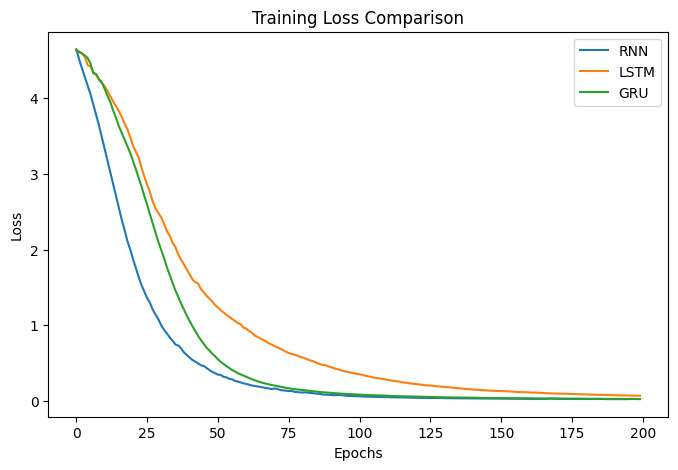

In [17]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history["loss"], label="RNN")
plt.plot(lstm_history.history["loss"], label="LSTM")
plt.plot(gru_history.history["loss"], label="GRU")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [18]:
def generate_text(seed_text, next_words, model):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding="pre")
        prediction = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(prediction)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text = seed_text + " " + output_word
    return seed_text

## Generate Text Samples

In [19]:
prompts = ["deep learning", "artificial intelligence", "neural networks"]

for prompt in prompts:
    print("Prompt:", prompt)
    print("RNN  :", generate_text(prompt, 10, rnn_model))
    print("LSTM :", generate_text(prompt, 10, lstm_model))
    print("GRU  :", generate_text(prompt, 10, gru_model))
    print()

Prompt: deep learning
RNN  : deep learning uses neural networks with many layers to learn complex patterns
LSTM : deep learning uses neural networks with many layers to learn complex patterns
GRU  : deep learning models can generate meaningful and coherent sentences sentences sentences content

Prompt: artificial intelligence
RNN  : artificial intelligence is the simulation of human intelligence by machines structure of
LSTM : artificial intelligence is the simulation of human intelligence by machines from data
GRU  : artificial intelligence is the simulation of human intelligence by machines machines from

Prompt: neural networks
RNN  : neural networks are inspired by the structure of the human brain based
LSTM : neural networks are inspired by the structure of the human brain simple
GRU  : neural networks are inspired by the structure of the human brain brain



In [20]:
print("Model\t\tFinal Loss\tFinal Accuracy")
print("RNN\t\t%.4f\t\t%.4f" % (rnn_history.history["loss"][-1], rnn_history.history["accuracy"][-1]))
print("LSTM\t\t%.4f\t\t%.4f" % (lstm_history.history["loss"][-1], lstm_history.history["accuracy"][-1]))
print("GRU\t\t%.4f\t\t%.4f" % (gru_history.history["loss"][-1], gru_history.history["accuracy"][-1]))

Model		Final Loss	Final Accuracy
RNN		0.0236		0.9925
LSTM		0.0670		0.9851
GRU		0.0238		0.9925


## Conclusion

- Among the three models, **LSTM and GRU learned better** than the Vanilla RNN, reaching lower training loss and higher accuracy in the same number of epochs.
- This happens because **Vanilla RNN suffers from the vanishing gradient problem**, which makes it hard to learn dependencies between words that are far apart in a sentence. LSTM and GRU use gates to control what information is kept or forgotten, so they remember long-term context much better.
- The **generated text from LSTM and GRU was more coherent** and closer to the patterns seen in the training corpus, while the RNN output was more repetitive and less meaningful.
- **Increasing the embedding dimension** allowed the model to capture richer relationships between words, which slightly improved the quality of predictions.
- **Increasing the hidden units from 64 to 128** gave the models more capacity to learn patterns from the corpus, which helped reduce training loss further.
- Training for **200 epochs** was necessary because the corpus is very small, so the models needed more passes over the data to learn meaningful word associations.
- **Future improvements** could include using a larger and more diverse corpus, adding more LSTM/GRU layers, using pre-trained word embeddings, or trying temperature-based sampling instead of plain argmax for more creative text generation.